In [1]:
import gzip
import itertools
import logging
from collections import Counter, defaultdict
from pathlib import Path
import pickle
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scipy.io
import scipy.sparse
from matplotlib.backends.backend_pdf import PdfPages

import subprocess
import os
import sys
import multiprocessing as mp

sys.path.append("/home/jsilverm/06_synapseseq_repo/synapse_seq_pipeline_code/09_dedup_aav_lib/")
import synapse_seq_functions as ssf


# Processing. Look at umis/vt

In [62]:
base_dir="/home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk"
region_name="PG"
run_id="bulk_dedup_412"

general_out_dir="/home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects"
out_dir = os.path.join(general_out_dir, region_name, run_id)

intermediate_dir = os.path.join(out_dir,"intermediate")
if not os.path.exists(intermediate_dir):
    os.mkdir(intermediate_dir)

In [ ]:
read_filters = [1, 10, 25, 50, 100]
umi_filters = [0, 1, 3, 5]
vt_hamming_k = 1

In [4]:

print(f"base_dir: {base_dir}")
print(f"region_name: {region_name}")
print(f"out_dir_general: {out_dir_general}")
print(f"run_id: {run_id}")

region_in_path = os.path.join(base_dir, region_name)
print(f"Checking that {region_in_path} exists")
assert os.path.exists(region_in_path), f"File {region_in_path} does not exist"

out_dir = os.path.join(out_dir_general, region_name, run_id)
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

tags_fname = "raw_tags.txt.gz"
raw_umis_fname = "raw_umis.txt.gz"
raw_umi_tag_fname = "umis_per_tags.txt.gz"

intermediate_dir_path = os.path.join(out_dir, "intermediate")
if not os.path.exists(intermediate_dir_path):
    os.makedirs(intermediate_dir_path)


#######################
    # Load data#
#######################
reads_per_umi_fname = "raw_read_umi_matrix.mtx.gz"
reads_per_umi_fname_full = os.path.join(region_in_path, reads_per_umi_fname)
print(f"Reading {reads_per_umi_fname_full}")
reads_per_umi_mat = scipy.io.mmread(reads_per_umi_fname_full)
reads_per_umi_mat = reads_per_umi_mat.tocsr()
umi_vt_mat = reads_per_umi_mat.T.tocsr()
print(reads_per_umi_mat.shape)

vt_listfname = "raw_tags.txt.gz"
vt_listfname_full = os.path.join(region_in_path, vt_listfname)
print(f"Reading {vt_listfname_full}")
vts = []
with gzip.open(vt_listfname_full, "rt") as f:
    for line in f:
        vts.append(line.strip())

umi_listfname = "raw_umis.txt.gz"
umi_listfname_full = os.path.join(region_in_path, umi_listfname)
print(f"Reading {umi_listfname_full}")
umis = []
with gzip.open(umi_listfname_full, "rt") as f:
    for line in f:
        umis.append(line.strip())

bulk_obj = {"umi_vt_mat": umi_vt_mat, "umis": umis, "vts": vts}



base_dir: /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk
region_name: PG
out_dir_general: /home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects
run_id: bulk_dedup_412
Checking that /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG exists
Reading /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG/raw_tags.txt.gz
Reading /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG/umis_per_tags.txt.gz


In [7]:
# Read in the hamming ball tree
aav_ball_tree_obj_path = "/home/jsilverm/06_synapseseq_repo/synapse_seq_pipeline_code/09_dedup_aav_lib/00_hamming_dist_objs/ball_tree_hamming_2.pkl"
with open(aav_ball_tree_obj_path, "rb") as fh:
    ball_tree_obj = pickle.load(fh)

ball_tree = ball_tree_obj['ball_tree']
inx_to_vt_seq_dict = ball_tree_obj['inx_to_seq_dict']



In [30]:
hamming_correction_results_out_path = os.path.join(intermediate_dir, "hamming_correction_results.pkl")
if os.path.exists(hamming_correction_results_out_path):
    print(f"Loading hamming correction results from {hamming_correction_results_out_path}")
    hamming_correction_results = pickle.load(open(hamming_correction_results_out_path, "rb"))
else:
    chunked_small_list = ssf.chunk_seq_list(bulk_obj["vts"], n_chunks=N_CHUNKS_HEAVY)
    radius = vt_hamming_k
    pool = mp.Pool(N_CORES_HEAVY)
    args = [(chunk, ball_tree, radius, inx) for inx, chunk in enumerate(chunked_small_list)]
    hamming_correction_results = pool.starmap(ssf.hamming_correct_seq_chunk, args)
    pool.close()
    pool.join()
    print(f"Writing hamming correction results to {hamming_correction_results_out_path}")
    # write results to file
    with open(hamming_correction_results_out_path, "wb") as fh:
        pickle.dump(hamming_correction_results, fh)

hamming_correction_results_unlisted = list(itertools.chain(*hamming_correction_results))

#Filter criteria:
# VT is not within specified hamming distance of any other VT. Seen as empty lists of neighbors
# VT is greater than 0 hamming distance away from more than 1 VT. (ie it is 1 HD away from 2 different VTs)
parsing_args = [(i, inx_to_vt_seq_dict) for i in hamming_correction_results_unlisted]
parsed_results = [ssf.parse_VT_hamming_result(*arg) for arg in parsing_args]

# Create map of observed VT to whitelist VT
whitelist_vt_to_observed_vt_inx = {}
observed_vt_to_whitelist_vt = {}
for i, result in enumerate(parsed_results):
    is_valid = result["is_valid_hamming"]
    if not is_valid:
        continue

    corrected_vt = result["corrected_VT"]
    observed_vt_inx = result["observed_VT_inx"]
    observed_vt_seq = result["observed_VT"]

    h_dist = ssf.do_basic_hamming(observed_vt_seq, corrected_vt)

    observed_vt_to_whitelist_vt[observed_vt_seq] = corrected_vt

Loading hamming correction results from /home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects/PG/bulk_dedup_412/intermediate/hamming_correction_results.pkl


In [37]:
# construct umat from corrected VT sequences
import tqdm

corrected_vts = list(whitelist_vt_to_observed_vt_inx.keys())
u_mat_vt_corrected_data_dict = defaultdict(Counter)
# Find nonzero entries in row.
# For each one, find the correct VT seq it maps to, if any, and add that as continuous sum to u_mat_vt_corrected dict
for i in tqdm.tqdm(range(bulk_obj["umi_vt_mat"].shape[0])):

    current_umi = bulk_obj["umis"][i]
    nonzero_entries = bulk_obj["umi_vt_mat"][i, :].nonzero()[1]

    for nonzero_entry_inx in nonzero_entries:
        vt_seq = bulk_obj["vts"][nonzero_entry_inx]
        corrected_vt = observed_vt_to_whitelist_vt.get(vt_seq, None)
        if corrected_vt is None:
            # this VT is not in the whitelist
            continue
        u_mat_vt_corrected_data_dict[current_umi][corrected_vt] += bulk_obj["umi_vt_mat"][i, nonzero_entry_inx]

# create a new u_mat with the corrected VTs
bead_umi_from_corrected_vt = sorted(list(u_mat_vt_corrected_data_dict.keys()))
vts_from_corrected_vt = sorted(set(i for v in u_mat_vt_corrected_data_dict.values() for i in v.keys()))
u_mat_vt_dedup = ssf.create_matrix(u_mat_vt_corrected_data_dict, bead_umi_from_corrected_vt, vts_from_corrected_vt)
vt_dedup_obj = {"umi_vt_mat": u_mat_vt_dedup, "umis": bead_umi_from_corrected_vt, "vts": vts_from_corrected_vt}


  0%|          | 0/209812 [00:00<?, ?it/s]

100%|██████████| 209812/209812 [00:32<00:00, 6401.44it/s]


In [42]:
umi_len = len(vt_dedup_obj["umis"][0])
vt_len = len(vt_dedup_obj["vts"][0])

In [41]:
def write_mock_fastq(group_name, umi_vts, size_umi, size_vt, mock_fastq_folder):
    current_fastq_path = os.path.join(mock_fastq_folder, f"{group_name}.fastq")
    # create mock fastq file
    read_size = size_umi + size_vt
    quality_string = "j" * read_size
    with open(current_fastq_path, "w") as fh:
        for umi_vt in umi_vts:
            umi = umi_vt["umi"]
            vt = umi_vt["vt"]
            count = umi_vt["count"]
            umi_vt = umi + vt
            for i in range(count):
                fh.write(f"@{group_name}\n")
                fh.write(f"{umi_vt}\n")
                fh.write(f"+\n")
                fh.write(f"{quality_string}\n")
    return current_fastq_path

def run_umi_vt_collapse(group_name, mock_fastq_folder, output_dir, log_base = "/home/jsilverm/logs"):
    mock_fastq_in = os.path.join(mock_fastq_folder, f"{group_name}.fastq")
    assert os.path.exists(mock_fastq_in)
    mock_fastq_out = os.path.join(output_dir, f"{group_name}_out.fastq")
    log_file = os.path.join(log_base, f"{group_name}_dedup_graph.log")
    cmd = f"umicollapse fastq -k 1 -i {mock_fastq_in} -o {mock_fastq_out} --tag > {log_file} 2>&1"
    os.system(cmd)



In [43]:
#########################################################
        # Run UMI deduplication #
    # For each bead, preform graph collapse on umi-VT seq #
#########################################################

# Create mock fastq and output dedup folders
mock_fastq_folder = os.path.join(intermediate_dir, "mock_fastq")
if not os.path.exists(mock_fastq_folder):
    os.makedirs(mock_fastq_folder)

umi_dedup_outdir = os.path.join(intermediate_dir, "umi_dedup_fastqs")
if not os.path.exists(umi_dedup_outdir):
    os.makedirs(umi_dedup_outdir)

# create a dictionary of bead to umi-vt's within it
bulk_fastq_dict = defaultdict(list)
n_rows_umi_mat = vt_dedup_obj["umi_vt_mat"].shape[0]
for i in range(n_rows_umi_mat):
    umi = vt_dedup_obj["umis"][i]
    nonzero_elements = vt_dedup_obj["umi_vt_mat"][i, :].nonzero()[1]
    for nonzero_element in nonzero_elements:
        vt = vt_dedup_obj["vts"][nonzero_element]
        read_count = vt_dedup_obj["umi_vt_mat"][i, nonzero_element]
        umi_vt = {"umi": umi, "vt": vt, "count": read_count}
        bulk_fastq_dict["bulk"].append(umi_vt)


# Create mock fastqs for umicollapse in parallel
print("Writing mock fastq")
write_mock_fastq(region_name, bulk_fastq_dict["bulk"], umi_len,vt_len, mock_fastq_folder)

# Run umicollapse
print("Running umicollapse")
run_umi_vt_collapse(region_name, mock_fastq_folder, umi_dedup_outdir)

print("Parsing umicollapse results")
bulk_umi_dedup_outs = ssf.parse_umi_collapse_results(region_name, umi_dedup_outdir)

Writing mock fastq
Running umicollapse
Parsing umicollapse results


In [44]:
u_mat_dedup_vt_umi_data_dict = defaultdict(Counter)
for i in tqdm.tqdm(range(vt_dedup_obj["umi_vt_mat"].shape[0])):
    current_umi = vt_dedup_obj["umis"][i]

    nonzero_vals = vt_dedup_obj["umi_vt_mat"][i, :].nonzero()[1]
    for nonzero_val in nonzero_vals:
        vt = vt_dedup_obj["vts"][nonzero_val]
        count = vt_dedup_obj["umi_vt_mat"][i, nonzero_val]

        umi_vt = current_umi + vt

        umi_vt_correction = bulk_umi_dedup_outs.get(umi_vt, None)
        if umi_vt_correction is None:
            print(f"None for {umi_vt}")
        assert umi_vt_correction is not None
        umi_corrected = umi_vt_correction[:umi_len]
        vt_corrected = umi_vt_correction[umi_len:]

        u_mat_dedup_vt_umi_data_dict[umi_corrected][vt_corrected] += count

umis_from_dict = sorted(list(u_mat_dedup_vt_umi_data_dict.keys()))
vts_from_dict = sorted(set(i for v in u_mat_dedup_vt_umi_data_dict.values() for i in v.keys()))

u_mat_umi_dedup = ssf.create_matrix(u_mat_dedup_vt_umi_data_dict, umis_from_dict, vts_from_dict)
u_mat_vt_and_umi_dedup_obj = {"u": u_mat_umi_dedup, "umis": umis_from_dict, "vts": vts_from_dict}


  1%|          | 617/101370 [00:00<00:16, 6166.40it/s]

100%|██████████| 101370/101370 [00:15<00:00, 6443.97it/s]


In [45]:
u_mat_dedup_max = ssf.filter_to_max_vt_per_cbumi(u_mat_vt_and_umi_dedup_obj["u"], u_mat_vt_and_umi_dedup_obj["umis"], u_mat_vt_and_umi_dedup_obj["vts"])
u_mat_dedup_max_obj = {"u": u_mat_dedup_max, "umis": u_mat_vt_and_umi_dedup_obj["umis"], "vts": u_mat_vt_and_umi_dedup_obj["vts"]}

In [ ]:
u_mat_out = os.path.join(intermediate_dir, "u_mat_dedup_max.pkl")
print(f"Writing u_mat to {u_mat_out}")
with open(u_mat_out, "wb") as fh:
    pickle.dump(u_mat_dedup_max_obj, fh)

# Plotting

In [93]:
pdf_out_name = os.path.join(out_dir, f"{region_name}_dedup_summary.pdf")
pp = PdfPages(pdf_out_name)

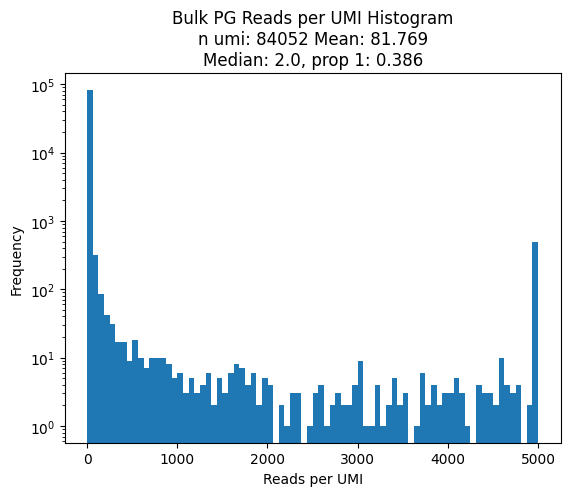

In [94]:
reads_umi_fig, ax = plt.subplots()
reads_per_umi = ssf.create_reads_umi_histogram(u_mat_dedup_max_obj["u"], title_base = f"Bulk {region_name}", truncate_value=5000, bins=80, ax=ax)
pp.savefig(reads_umi_fig)


  0%|          | 0/4 [00:00<?, ?it/s]

Creating new m_mat


51596it [00:05, 9020.36it/s]
 25%|██▌       | 1/4 [00:06<00:18,  6.23s/it]

Creating new m_mat


9812it [00:01, 9065.82it/s]
 50%|█████     | 2/4 [00:07<00:06,  3.38s/it]

Creating new m_mat


1448it [00:00, 9023.80it/s]
 75%|███████▌  | 3/4 [00:08<00:02,  2.24s/it]

Creating new m_mat


1044it [00:00, 8904.58it/s]
100%|██████████| 4/4 [00:08<00:00,  2.22s/it]


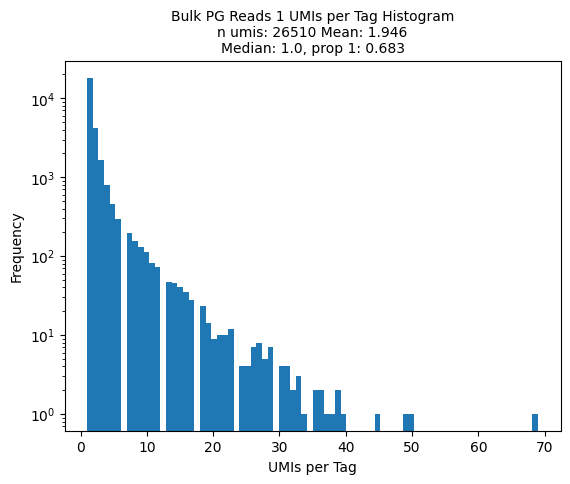

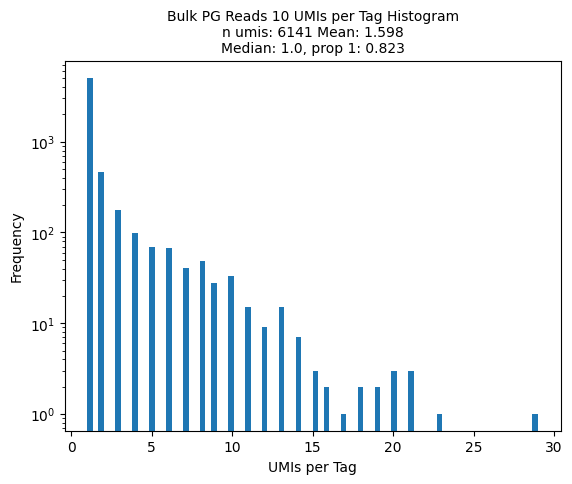

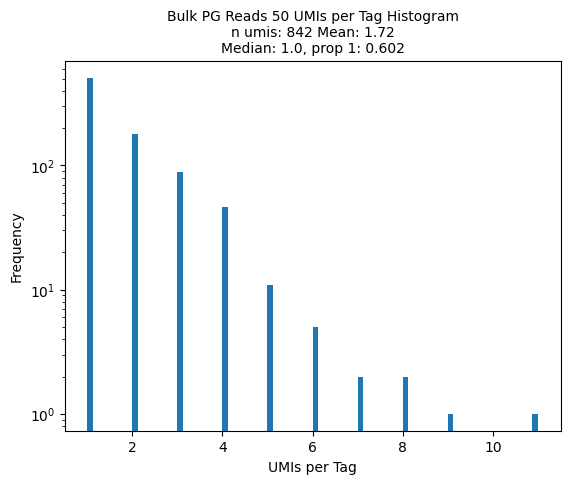

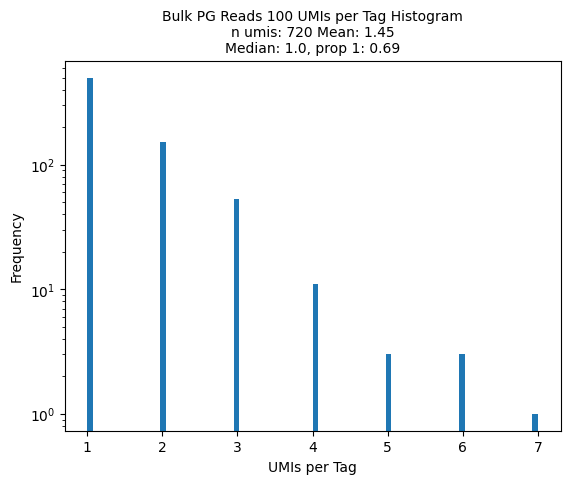

In [99]:
tags_out_base = os.path.join(out_dir, "vts_filt")
if not os.path.exists(tags_out_base):
    os.mkdir(tags_out_base)

n_tags_w_filts_result = {"read_filt": [], "umi_filt": [], "n_tags": []}

for read_filter in tqdm.tqdm(read_filters):
    # apply read filter to umis
    u_mat_filtered = ssf.create_u_and_m_mat_from_read_filter(u_mat_dedup_max_obj["u"], u_mat_dedup_max_obj["umis"],u_mat_dedup_max_obj["vts"], read_filter, cb_split_inx=0)
    # make umi/tag plot
    reads_umi_fig, ax = plt.subplots()
    reads_per_umi = ssf.create_umi_per_tag_histogram(u_mat_filtered["m_mat"], title_base = f"Bulk {region_name} Reads {read_filter}", bins=80, ax=ax)
    pp.savefig(reads_umi_fig)
    # save resulting tags
    for umi_filter in umi_filters:
        # identify tags above umi_filter
        flat_m = u_mat_filtered["m_mat"].toarray()
        vt_indices_above_thresh = np.where(flat_m > umi_filter)[1]
        vts_included = [u_mat_filtered["vts"][i] for i in vt_indices_above_thresh]
        vts_set = set(vts_included)

        n_tags = len(vts_set)
        n_tags_w_filts_result["read_filt"].append(read_filter)
        n_tags_w_filts_result["umi_filt"].append(umi_filter)
        n_tags_w_filts_result["n_tags"].append(n_tags)

        pkl_out = os.path.join(tags_out_base, "vts.pkl")
        with open(pkl_out, "wb") as f:
            pickle.dump(vts_set, f)

n_tags_results_df = pd.DataFrame(n_tags_w_filts_result)

In [91]:
pp.close()

In [2]:
import pickle
p = "/home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects/PG/dedup_test/intermediate/u_mat_dedup_max.pkl"
with open(p, "rb") as f:
    u_mat_dedup_max_obj = pickle.load(f)

In [4]:
# base_dir = args.base_dir
# region_name = args.region_name
# out_dir_general = args.out_dir_general
# run_id = args.run_id
# is_test = args.is_test
base_dir="/home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk"
region_name="PG"
run_id="bulk_dedup_412"
out_dir_general="/home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects"
is_test=True

print(f"base_dir: {base_dir}")
print(f"region_name: {region_name}")
print(f"out_dir_general: {out_dir_general}")
print(f"run_id: {run_id}")
print(f"is_test: {is_test}")

region_in_path = os.path.join(base_dir, region_name)
print(f"Checking that {region_in_path} exists")
assert os.path.exists(region_in_path), f"File {region_in_path} does not exist"

# Create output dir if it doesn't exist already
out_dir = os.path.join(out_dir_general, region_name, run_id)
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

print(f"Working out_dir: {out_dir}")

intermediate_dir = os.path.join(out_dir,"intermediate")
if not os.path.exists(intermediate_dir):
    os.mkdir(intermediate_dir)


# Create intermediate dir if it doesn't exist already. Used to store computed files
intermediate_dir_path = os.path.join(out_dir, "intermediate")
if not os.path.exists(intermediate_dir_path):
    os.makedirs(intermediate_dir_path)

sys.stderr.flush()
sys.stdout.flush()

#######################
    # Load data#
#######################

# Hard coded local file names
reads_per_umi_fname = "raw_read_umi_matrix.mtx.gz"
vt_listfname = "raw_tags.txt.gz"
umi_listfname = "raw_umis.txt.gz"

# Read in umi-vt matrix to be umixvt in csr form
reads_per_umi_fname_full = os.path.join(region_in_path, reads_per_umi_fname)
print(f"Reading {reads_per_umi_fname_full}")
reads_per_umi_mat = scipy.io.mmread(reads_per_umi_fname_full)
reads_per_umi_mat = reads_per_umi_mat.tocsr()
umi_vt_mat = reads_per_umi_mat.T.tocsr()
print(reads_per_umi_mat.shape)

# Read in list of VTs and UMIs
vt_listfname_full = os.path.join(region_in_path, vt_listfname)
print(f"Reading {vt_listfname_full}")
vts = []
with gzip.open(vt_listfname_full, "rt") as f:
    for line in f:
        vts.append(line.strip())

umi_listfname_full = os.path.join(region_in_path, umi_listfname)
print(f"Reading {umi_listfname_full}")
umis = []
with gzip.open(umi_listfname_full, "rt") as f:
    for line in f:
        umis.append(line.strip())

bulk_obj = {"umi_vt_mat": umi_vt_mat, "umis": umis, "vts": vts}


sys.stderr.flush()
sys.stdout.flush()


# If test subset matrix to first 1000 umi and vts
if is_test:
    print("IS TEST. SUbsetting UMI and VTs")
    bulk_obj["umi_vt_mat"] = bulk_obj["umi_vt_mat"][:1000, :1000]
    bulk_obj["umis"] = bulk_obj["umis"][:1000]
    bulk_obj["vts"] = bulk_obj["vts"][:1000]
    N_CHUNKS_HEAVY=2
    N_CORES_HEAVY=10



base_dir: /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk
region_name: PG
out_dir_general: /home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects
run_id: bulk_dedup_412
is_test: True
Checking that /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG exists
Working out_dir: /home/jsilverm/06_synapseseq_repo/data/V1_Processing/02_bulk_dissects/PG/bulk_dedup_412


Reading /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG/raw_read_umi_matrix.mtx.gz
(319691, 209812)
Reading /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG/raw_tags.txt.gz
Reading /home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/bulk/PG/raw_umis.txt.gz
IS TEST. SUbsetting UMI and VTs


In [6]:
bulk_obj["umi_vt_mat"]

<1000x1000 sparse matrix of type '<class 'numpy.int64'>'
	with 11 stored elements in Compressed Sparse Row format>